# Baseline Model — IndoReview Intelligence

This notebook establishes a majority-class baseline before training a text classification model.

In [9]:
from pathlib import Path

import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
)

from indoreview.data import (
    clean_training_data,
    load_raw_splits,
)


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"

In [10]:
raw_splits = load_raw_splits(DATA_DIR)

train_df = clean_training_data(
    raw_splits["train"],
    raw_splits["validation"],
    raw_splits["test"],
)

validation_df = raw_splits["validation"]

print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(validation_df):,}")

Training rows   : 10,919
Validation rows : 1,260


In [11]:
X_train = train_df["text"]
y_train = train_df["label"]

X_validation = validation_df["text"]
y_validation = validation_df["label"]

LABEL_ORDER = [
    "negative",
    "neutral",
    "positive",
]

In [12]:
dummy_model = DummyClassifier(
    strategy="most_frequent",
)

dummy_model.fit(
    X_train,
    y_train,
)

validation_predictions = dummy_model.predict(
    X_validation,
)

In [13]:
baseline_metrics = pd.Series({
    "accuracy": accuracy_score(
        y_validation,
        validation_predictions,
    ),
    "macro_f1": f1_score(
        y_validation,
        validation_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
})

baseline_metrics.round(4)

accuracy    0.5833
macro_f1    0.2456
dtype: float64

In [14]:
classification_report_data = classification_report(
    y_validation,
    validation_predictions,
    labels=LABEL_ORDER,
    output_dict=True,
    zero_division=0,
)

classification_report_df = (
    pd.DataFrame(classification_report_data)
    .transpose()
    .round(3)
)

classification_report_df

,precision,recall,f1-score,support
negative,0.000,0.000,0.000,394.000
neutral,0.000,0.000,0.000,131.000
positive,0.583,1.000,0.737,735.000
accuracy,0.583,0.583,0.583,0.583
macro avg,0.194,0.333,0.246,1260.000
weighted avg,0.340,0.583,0.430,1260.000


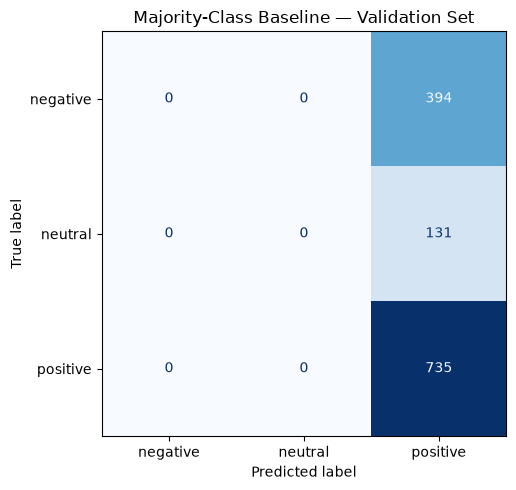

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_predictions,
    labels=LABEL_ORDER,
    display_labels=LABEL_ORDER,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax,
)

ax.set_title("Majority-Class Baseline — Validation Set")

plt.tight_layout()
plt.show()

### Majority-Class Baseline Findings

The majority-class baseline predicts **positive** for every validation
example because positive is the most frequent training label.

It correctly classifies all 735 positive examples, but misclassifies all
394 negative examples and 131 neutral examples as positive.

The model achieves 58.33% accuracy but only 24.56% macro F1. Therefore,
accuracy alone is misleading for this imbalanced dataset, and macro F1
will be used as the primary model-selection metric.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


tfidf_logreg_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42,
        ),
    ),
])

tfidf_logreg_model.fit(
    X_train,
    y_train,
)

tfidf_validation_predictions = tfidf_logreg_model.predict(
    X_validation,
)

In [17]:
tfidf_metrics = pd.Series({
    "accuracy": accuracy_score(
        y_validation,
        tfidf_validation_predictions,
    ),
    "macro_f1": f1_score(
        y_validation,
        tfidf_validation_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
})

model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        tfidf_metrics,
    ],
    index=[
        "majority_baseline",
        "tfidf_logreg",
    ],
)

model_comparison.round(4)

,accuracy,macro_f1
majority_baseline,0.5833,0.2456
tfidf_logreg,0.8714,0.8339


In [18]:
tfidf_report_data = classification_report(
    y_validation,
    tfidf_validation_predictions,
    labels=LABEL_ORDER,
    output_dict=True,
    zero_division=0,
)

tfidf_report_df = (
    pd.DataFrame(tfidf_report_data)
    .transpose()
    .round(3)
)

tfidf_report_df

,precision,recall,f1-score,support
negative,0.812,0.853,0.832,394.000
neutral,0.888,0.664,0.760,131.000
positive,0.902,0.918,0.910,735.000
accuracy,0.871,0.871,0.871,0.871
macro avg,0.867,0.812,0.834,1260.000
weighted avg,0.872,0.871,0.870,1260.000


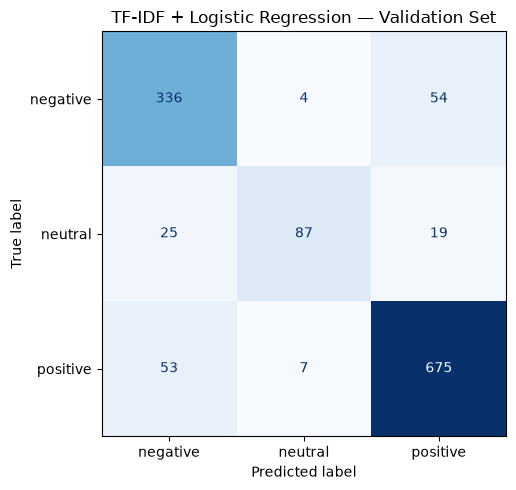

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    tfidf_validation_predictions,
    labels=LABEL_ORDER,
    display_labels=LABEL_ORDER,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax,
)

ax.set_title(
    "TF-IDF + Logistic Regression — Validation Set"
)

plt.tight_layout()
plt.show()

### TF-IDF Logistic Regression Findings

The TF-IDF Logistic Regression model correctly classified 1,098 of
1,260 validation examples, achieving 87.14% accuracy and 83.39% macro F1.

The positive class achieved the highest F1-score at 0.910, while neutral
had the lowest F1-score at 0.760. Neutral recall was only 0.664, indicating
that the model missed 44 of the 131 neutral examples.

The most frequent error was predicting negative examples as positive
(54 cases), closely followed by predicting positive examples as negative
(53 cases).

In [20]:
balanced_tfidf_logreg_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1),
            min_df=2,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
    ),
])

balanced_tfidf_logreg_model.fit(
    X_train,
    y_train,
)

balanced_validation_predictions = (
    balanced_tfidf_logreg_model.predict(
        X_validation,
    )
)

In [21]:
balanced_metrics = pd.Series({
    "accuracy": accuracy_score(
        y_validation,
        balanced_validation_predictions,
    ),
    "macro_f1": f1_score(
        y_validation,
        balanced_validation_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
})

model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        tfidf_metrics,
        balanced_metrics,
    ],
    index=[
        "majority_baseline",
        "tfidf_logreg",
        "tfidf_logreg_balanced",
    ],
)

model_comparison.round(4)

,accuracy,macro_f1
majority_baseline,0.5833,0.2456
tfidf_logreg,0.8714,0.8339
tfidf_logreg_balanced,0.8619,0.8292


In [22]:
balanced_report_data = classification_report(
    y_validation,
    balanced_validation_predictions,
    labels=LABEL_ORDER,
    output_dict=True,
    zero_division=0,
)

balanced_report_df = (
    pd.DataFrame(balanced_report_data)
    .transpose()
    .round(3)
)

balanced_report_df

,precision,recall,f1-score,support
negative,0.811,0.863,0.836,394.000
neutral,0.665,0.863,0.751,131.000
positive,0.943,0.861,0.900,735.000
accuracy,0.862,0.862,0.862,0.862
macro avg,0.807,0.862,0.829,1260.000
weighted avg,0.873,0.862,0.865,1260.000


### Class Weight Experiment

Using balanced class weights increased neutral recall from 0.664 to 0.863.
However, neutral precision decreased substantially from 0.888 to 0.665,
causing its F1-score to decrease from 0.760 to 0.751.

Overall accuracy decreased from 0.8714 to 0.8619, while macro F1 decreased
from 0.8339 to 0.8292. Therefore, balanced class weights were not selected
for the final classical model.

In [23]:
bigram_tfidf_logreg_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42,
        ),
    ),
])

bigram_tfidf_logreg_model.fit(
    X_train,
    y_train,
)

bigram_validation_predictions = (
    bigram_tfidf_logreg_model.predict(
        X_validation,
    )
)

In [24]:
bigram_metrics = pd.Series({
    "accuracy": accuracy_score(
        y_validation,
        bigram_validation_predictions,
    ),
    "macro_f1": f1_score(
        y_validation,
        bigram_validation_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
})

model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        tfidf_metrics,
        balanced_metrics,
        bigram_metrics,
    ],
    index=[
        "majority_baseline",
        "tfidf_unigram",
        "tfidf_unigram_balanced",
        "tfidf_unigram_bigram",
    ],
)

model_comparison.round(4)

,accuracy,macro_f1
majority_baseline,0.5833,0.2456
tfidf_unigram,0.8714,0.8339
tfidf_unigram_balanced,0.8619,0.8292
tfidf_unigram_bigram,0.8794,0.8310


### Classical Model Selection

The unigram and bigram model achieved the highest accuracy at 0.8794,
but its macro F1 of 0.8310 was slightly lower than the unigram model's
macro F1 of 0.8339.

Because macro F1 was selected as the primary metric before model
comparison, the unweighted unigram TF-IDF Logistic Regression model
was selected as the best classical model.

In [25]:
validation_probabilities = (
    tfidf_logreg_model.predict_proba(
        X_validation,
    )
)

validation_results = validation_df.copy()

validation_results["predicted_label"] = (
    tfidf_validation_predictions
)

validation_results["confidence"] = (
    validation_probabilities
    .max(axis=1)
    .round(4)
)

validation_results["is_correct"] = (
    validation_results["label"]
    == validation_results["predicted_label"]
)

validation_errors = (
    validation_results.loc[
        ~validation_results["is_correct"]
    ]
    .copy()
)

print(
    f"Validation errors: "
    f"{len(validation_errors):,}"
)

Validation errors: 162


In [26]:
pd.set_option(
    "display.max_colwidth",
    200,
)

high_confidence_errors = (
    validation_errors[
        [
            "text",
            "label",
            "predicted_label",
            "confidence",
        ]
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
    .head(10)
)

high_confidence_errors

,text,label,predicted_label,confidence
442,tidak marah,positive,negative,0.9731
121,saya tidak kecewa dengan prabowo,positive,negative,0.9686
629,makanya saya minta bukti valid kebenaran nya apa iya harga bbm yang dijual pemerintah era say mahal mencekik masyarakat sana ? karena menurut orang-orang amp ; orang papua kata nya harga bbm itu s...,neutral,negative,0.9679
806,tidak rusak,positive,negative,0.9654
967,otak kita itu canggih banget lo,positive,negative,0.9477
729,"padanan ayam dan keju cair cukup enak , karena memberi rasa kenyang , untuk hot chicken wings cukup enak . untuk pesta ulang tahun anak cukup luas dan open air",negative,positive,0.9459
1193,"suasana enak . rasa makanan juga enak , walau menurut saya kurang cocok dengan harga . restoran cukup luas , banyak tempat duduk . meskipun beberapa ulasan kurang bagus , waktu saya ke sana - rest...",negative,positive,0.9351
208,pemandangan nya bagus tapi kalau mau ke sini baiknya reservasi dulu kalau mau dapat tempat yang bagus . makanan nya enak banget apalagi iga nya tapi lama sekali dan seringkali dianggurkan sama pel...,negative,positive,0.9240
100,tidak iri,positive,negative,0.9150
1040,aku tidak marah pada indosat walaupun sinyal nya sering meredup,positive,negative,0.9061


### Error Analysis Findings

Several high-confidence errors contain negated expressions such as
"tidak marah", "tidak kecewa", "tidak rusak", and "tidak iri".
The unigram model treats words independently, so negative words such
as "marah" and "kecewa" can dominate even when preceded by negation.

Other errors contain mixed sentiment. Reviews may include positive words
such as "enak" and "bagus" while also expressing complaints. TF-IDF
Logistic Regression cannot fully understand contrast, word order, or
which part of a review determines its overall sentiment.

These errors motivate a future comparison with a contextual language
model such as IndoBERT.

In [27]:
test_df = raw_splits["test"]

X_test = test_df["text"]
y_test = test_df["label"]

classical_test_predictions = (
    tfidf_logreg_model.predict(
        X_test,
    )
)

classical_test_metrics = pd.Series({
    "accuracy": accuracy_score(
        y_test,
        classical_test_predictions,
    ),
    "macro_f1": f1_score(
        y_test,
        classical_test_predictions,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0,
    ),
})

classical_test_metrics.round(4)

accuracy    0.7600
macro_f1    0.6948
dtype: float64

In [28]:
classical_test_report_data = classification_report(
    y_test,
    classical_test_predictions,
    labels=LABEL_ORDER,
    output_dict=True,
    zero_division=0,
)

classical_test_report_df = (
    pd.DataFrame(classical_test_report_data)
    .transpose()
    .round(3)
)

classical_test_report_df

,precision,recall,f1-score,support
negative,0.684,0.956,0.798,204.00
neutral,0.857,0.341,0.488,88.00
positive,0.861,0.745,0.799,208.00
accuracy,0.760,0.760,0.760,0.76
macro avg,0.801,0.681,0.695,500.00
weighted avg,0.788,0.760,0.744,500.00


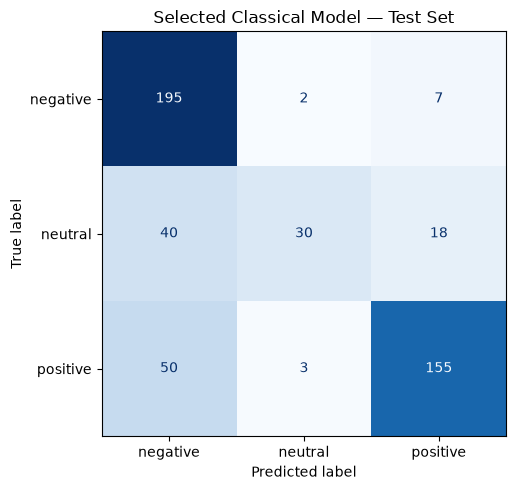

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    classical_test_predictions,
    labels=LABEL_ORDER,
    display_labels=LABEL_ORDER,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax,
)

ax.set_title(
    "Selected Classical Model — Test Set"
)

plt.tight_layout()
plt.show()

### Final Test Results

The selected unigram TF-IDF Logistic Regression model achieved 0.7600
accuracy and 0.6948 macro F1 on the held-out test set, correctly
classifying 380 of 500 examples.

Performance was strongest for positive and negative sentiment, with
F1-scores of 0.799 and 0.798. Neutral sentiment was considerably more
difficult, achieving an F1-score of 0.488 and recall of only 0.341.

The largest error group consisted of 50 positive examples predicted as
negative, followed by 40 neutral examples predicted as negative.

The performance gap between validation and test results indicates a
generalization challenge and possible differences in text or label
distribution between the splits. No model changes were made based on
the test results.